## Import Necessary Libraries

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
print(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from data.data_loader import load_datasets, get_dataloaders
from data.preprocessing import get_transforms
from utils.config import load_config
from utils.helpers import FASHION_MNIST_CLASSES

print("Libraries and Custom Modules Loaded.")

H:\VSCode\Python\fashion-mnist-classifier\src
Libraries and Custom Modules Loaded.


## Load Configuration from config.yaml

In [2]:
config_path = '../configs/config.yaml'
config = load_config(config_path)

data_config = config['data']
training_config = config['training']
paths_config = config['paths']

print("Configuration Loaded:")
print(f"\tRaw Data Path: {data_config['raw_data_path']}")
print(f"\tBatch Size: {training_config['batch_size']}")
print(f"\tInput Shape: {tuple(data_config['input_shape'])}")
print(f"\tNumber of Classes: {data_config['num_classes']}")
print(f"\tFigures Save Directory: {paths_config['figures_save_dir']}")

# Ensure Directory Exists
os.makedirs(paths_config['figures_save_dir'], exist_ok=True)

Configuration Loaded:
	Raw Data Path: data/raw
	Batch Size: 64
	Input Shape: (1, 28, 28)
	Number of Classes: 10
	Figures Save Directory: results/figures/


## Load Datasets and Create DataLoaders

In [3]:
transform = get_transforms()

# Load Datasets
train_dataset, test_dataset = load_datasets(raw_data_path=data_config['raw_data_path'], transforms=transform)

# Create DataLoaders
train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=16, num_workers=0)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")
print(f"Train DataLoader Batch Size: {train_loader.batch_size}")

Fashion MNIST datasets successfully loaded.  Train Samples: 60000 	 Test Samples: 10000
DataLoaders created with batch size: 16
Train Dataset Size: 60000
Test Dataset Size: 10000
Train DataLoader Batch Size: 16


## Display Sample Images

Shape of image batch: torch.Size([16, 1, 28, 28])
Shape of label batch: torch.Size([16])


C:\Users\radix\anaconda3\envs\py311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


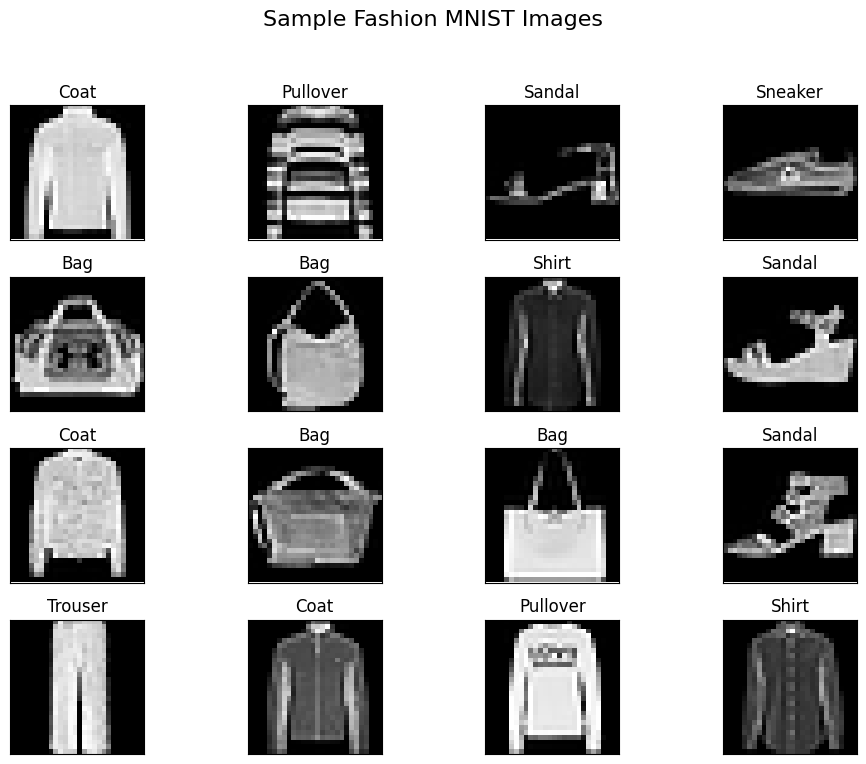

 Sample images plot saved to: results/figures/sample_fashion_mnist_images.png


In [4]:
images, labels = next(iter(train_loader))

print(f"Shape of image batch: {images.shape}")
print(f"Shape of label batch: {labels.shape}")

# Denormalize images
display_images = (images * 0.5 + 0.5).clamp(0,1)

# Create Grid of images
fig = plt.figure(figsize=(10, 8))
for i in range(len(display_images)):
    if i >= 16:
        break
    ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
    ax.imshow(display_images[i].squeeze(), cmap='gray')
    ax.set_title(FASHION_MNIST_CLASSES[labels[i]])
plt.suptitle("Sample Fashion MNIST Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save Plot
sample_images_path = os.path.join(paths_config['figures_save_dir'], 'sample_fashion_mnist_images.png')
plt.savefig(sample_images_path)
plt.show()
print(f" Sample images plot saved to: {sample_images_path}")

## Analyze Class Distribution

Training Set -- Class Distribution:
	T-Shirt/Top: 6000 samples
	Trouser: 6000 samples
	Pullover: 6000 samples
	Dress: 6000 samples
	Coat: 6000 samples
	Sandal: 6000 samples
	Shirt: 6000 samples
	Sneaker: 6000 samples
	Bag: 6000 samples
	Ankle Boot: 6000 samples

Test Set -- Class Distribution
	T-Shirt/Top: 1000 samples
	Trouser: 1000 samples
	Pullover: 1000 samples
	Dress: 1000 samples
	Coat: 1000 samples
	Sandal: 1000 samples
	Shirt: 1000 samples
	Sneaker: 1000 samples
	Bag: 1000 samples
	Ankle Boot: 1000 samples


C:\Users\radix\AppData\Local\Temp\ipykernel_6548\1685857654.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.05])


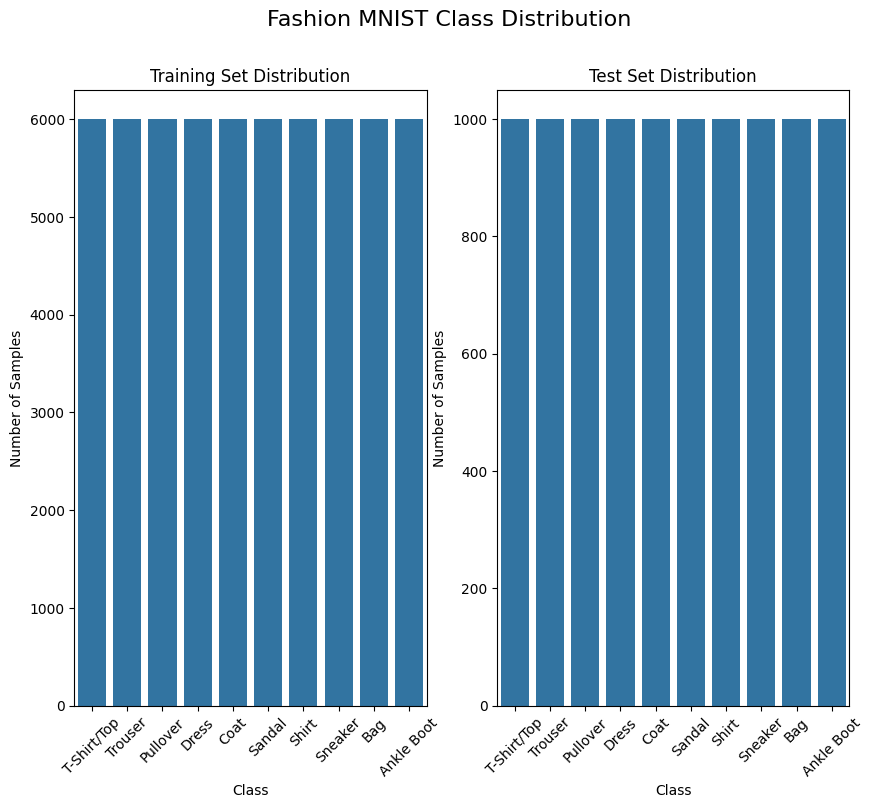

Class distribution plot saved to: results/figures/fashion_mnist_class_distribution.png


In [5]:
# Collect labels
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

# Convert labels to numpy arrays
train_labels_np = np.array(train_labels)
test_labels_np = np.array(test_labels)

# Count Class Occurrences
train_class_counts = np.bincount(train_labels_np, minlength=data_config['num_classes'])
test_class_counts = np.bincount(test_labels_np, minlength=data_config['num_classes'])

print("Training Set -- Class Distribution:")
for i, count in enumerate(train_class_counts):
    print(f"\t{FASHION_MNIST_CLASSES[i]}: {count} samples")

print("\nTest Set -- Class Distribution")
for i, count in enumerate(test_class_counts):
    print(f"\t{FASHION_MNIST_CLASSES[i]}: {count} samples")

# Plot Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
fig.suptitle("Fashion MNIST Class Distribution", fontsize=16)

sns.barplot(x=FASHION_MNIST_CLASSES, y= train_class_counts, ax=axes[0])
axes[0].set_title("Training Set Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x',rotation=45)

sns.barplot(x=FASHION_MNIST_CLASSES, y=test_class_counts, ax=axes[1])
axes[1].set_title("Test Set Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.05])

# Save Plot
class_dist_path = os.path.join(paths_config['figures_save_dir'], 'fashion_mnist_class_distribution.png')
plt.savefig(class_dist_path)
plt.show()
print(f"Class distribution plot saved to: {class_dist_path}")

## Summary -- Observations

In [6]:
print("----- Observations from EDA -----")
print("1. Data Loading: Verified data can be loaded efficiently using PyTorch DataLoaders.")
print("\n2. Image Preprocessing: \Verified images are correctly converted to tensors, normalized to [-1, 1], and reshaped to (Channel, Height, Width).")
print("\n3. Sample Visualization: Displayed sample images. Verified correct labeling.")
print("\n4. Class Distribution: Observed Fashion MNIST distribution in both the train and test sets.")
print("\n===== EDA Complete =====")

----- Observations from EDA -----
1. Data Loading: Verified data can be loaded efficiently using PyTorch DataLoaders.

2. Image Preprocessing: \Verified images are correctly converted to tensors, normalized to [-1, 1], and reshaped to (Channel, Height, Width).

3. Sample Visualization: Displayed sample images. Verified correct labeling.

4. Class Distribution: Observed Fashion MNIST distribution in both the train and test sets.

===== EDA Complete =====
